In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score

In [2]:
data=pd.read_csv('iris.csv')

In [3]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [6]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.3,random_state=1)

In [7]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
y_pred=knn.predict(x_test)

In [9]:
cm=confusion_matrix(y_test,y_pred)
classes=np.unique(y_test)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[14  0  0]
 [ 0 17  1]
 [ 0  0 13]]


In [10]:
acc=accuracy_score(y_test,y_pred)
error=1-acc
ps=precision_score(y_test,y_pred,average='macro')
recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy : ",acc*100)
print("Error Rate : ",error*100)
print("Precision : ",ps*100)
print("Recall : ",recall*100)

Accuracy :  97.77777777777777
Error Rate :  2.2222222222222254
Precision :  97.61904761904762
Recall :  98.14814814814815


In [11]:
print("Classification Report")
print(classification_report(y_test,y_pred))

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       1.00      0.94      0.97        18
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



In [12]:
print("Classification Report")
print(classification_report(y_test,y_pred))

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       1.00      0.94      0.97        18
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



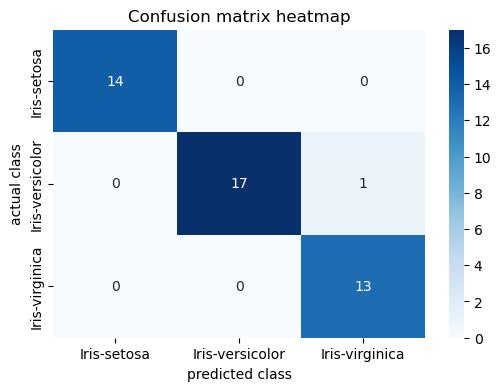

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=classes,yticklabels=classes)
plt.title("Confusion matrix heatmap")
plt.xlabel("predicted class")
plt.ylabel("actual class")
plt.show()